# Lidando com a incerteza

Este é um material de consulta sobre o sexto tópico de estudos. Sinta-se a vontade para voltar aqui sempre que necessário.

## Índice :
* [Amostras e Populações](#first-bullet)
* [Probabilidade e Curva Normal](#second-bullet)


## Amostras e Populações <a class="anchor" id="first-bullet"></a>

"População" e "universo" são termos técnicos em estatística que indicam a totalidade de observações com uma determinada característica. 

Imagine uma busca de jurisprudência no site de um tribunal por todas as decisões que incluem a expressão "discurso de ódio".

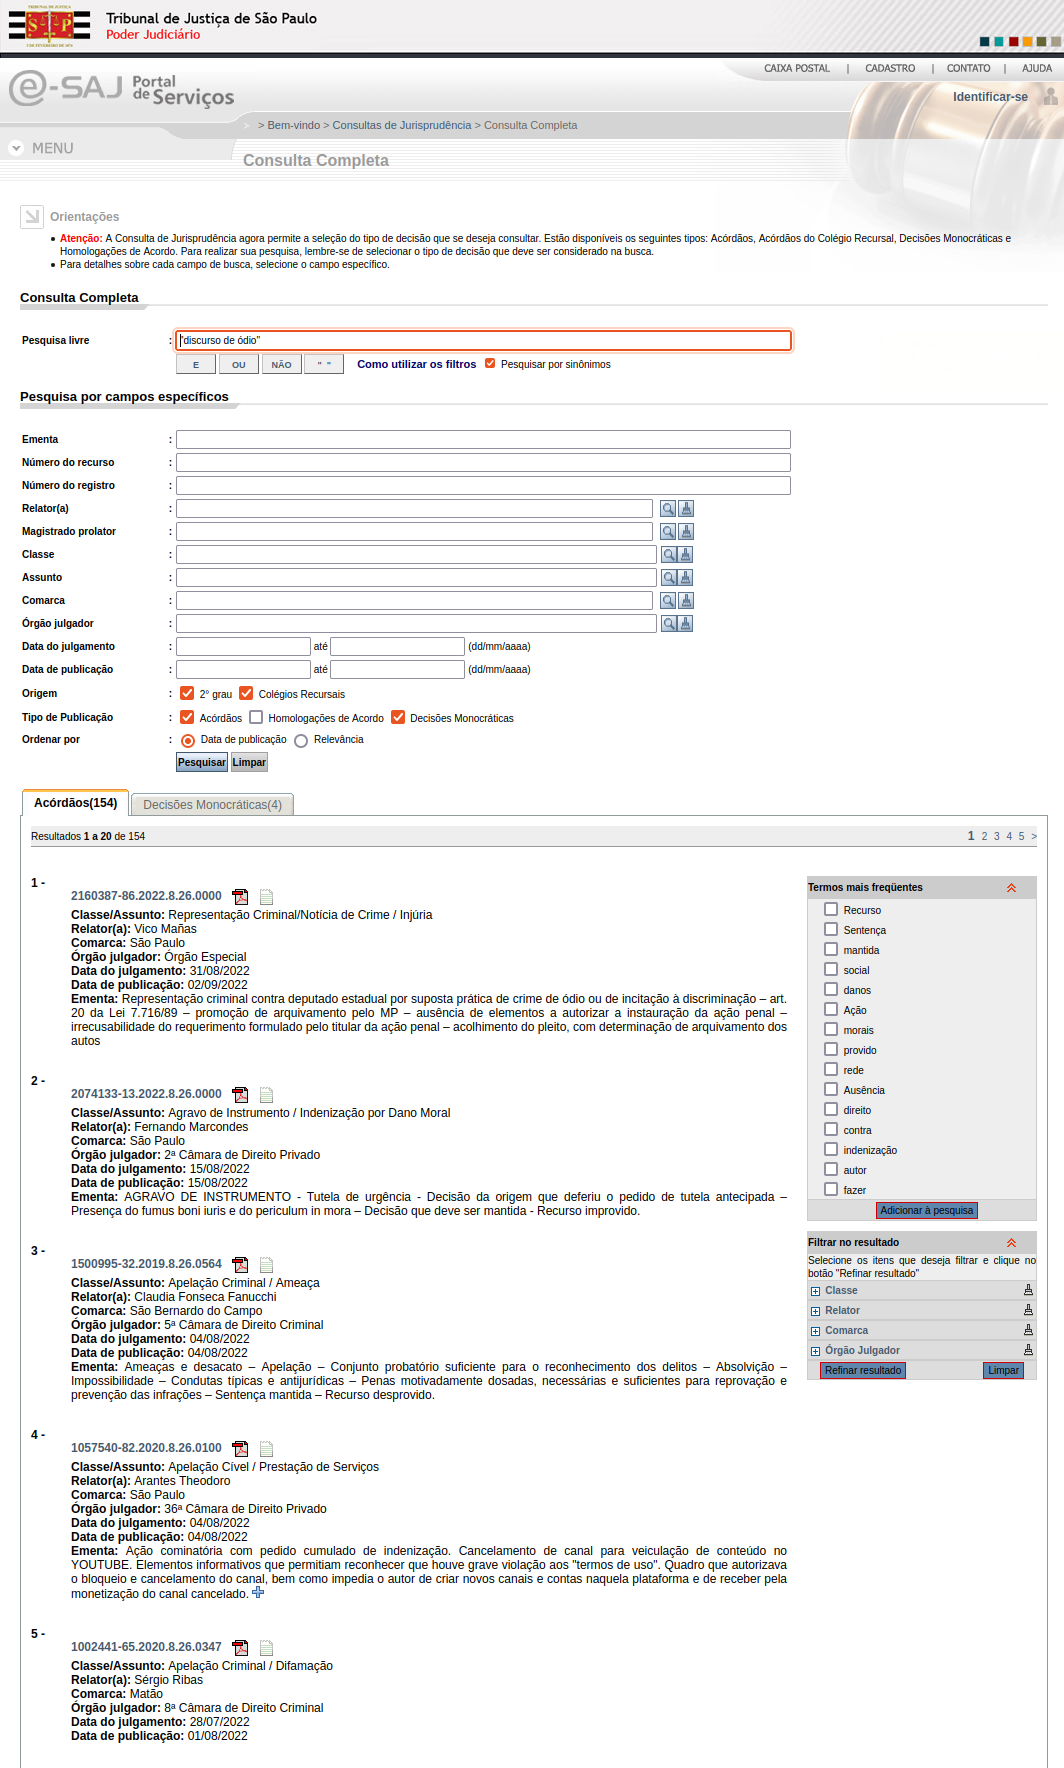

No caso do TJ-SP o universo de decisões de 2a instância que incluem, no seu inteiro teor, a expressão "discurso de ódio" é de 154 decisões.

É juridicamente relevante para um escritório que atua no contencioso cível saber o valor das indenizações fixadas nos casos em que a parte ré é condenada a indenizar danos morais. Um caminho possível é ler cada uma das 154 decisões ou ler cada uma das 154 decisões em apelações cíveis. 

Ao lidar com decisões judiciais, normalmente a informação que precisamos extrair de cada decisão faz com que a leitura de 154 decisões seja custosa demais. Além disso, muitas vezes o universo de decisões é muito maior do que 154, ficando nos milhares ou dezenas de milhares.

É possível analisar uma amostra dessas decisões e produzir informações que podem ser atribuídas ao universo delas. **Essa amostra deve ser aleatória: ao escolher cada uma das decisões que irá compor a amostra, todas as decisões do universo devem ter iguais chances de seleção.**

Uma opção é produzir uma lista com o número de cada processo encontrado e realizar o sorteio aleatório com Python. 

Em nossa base de dados de decisões colegiadas do STF, a população ou universo de decisões é constituído pelo total de decisões na base. Cada linha é uma decisão, então nosso universo é o total de linhas.  

In [ ]:
stf = pd.read_csv('/content/drive/MyDrive/Pastas Sincronizadas/Insper/Graduação/Ciência de Dados Aplicada ao Direito/Notebooks/CDAD2/colegiadas_stf.csv',encoding='UTF-8')
len(stf)

61930

Nesse caso, sabemos a média de dias até a decisão para o universo porque temos os dados completos.

In [ ]:
stf.dias_decisao.mean()

340.81763281123847

A realidade normalmente é diferente. Muitas vezes a informação sobre a média de um conjunto de dados não está disponível - por exemplo, a média de dias até o final de um procedimento na Comissão de Valores Mobiliários.

A amostra aleatória de observações é uma maneira de produzir a informação necessária sobre determinada característica da *totalidade das observações* sem, no entanto, ter acesso a essa totalidade. Pesquisas de intenção de voto são talvez o exemplo mais conhecido de dado amostral. Um instituto não tem tempo ou recursos para perguntar para mais de 150 milhões de eleitores a sua intenção individual de voto, portanto realiza a pergunta para uma amostra aleatória de eleitores e calcula a informação para o universo de eleitores usando uma margem de erro.

O tamanho da amostra importa. Vamos extrair uma amostra de decisões da base de dados e comparar a média de dias até a decisão na amostra e no universo.

In [ ]:
media_universo = stf.dias_decisao.mean()

def amostra_decisoes(total_decisoes):
  amostra = stf.dias_decisao.sample(n=total_decisoes)
  media_amostra = amostra.mean()
  plt.hist(amostra,range=(1,3000),bins=50)
  plt.axvline(media_amostra,label='Média Amostra',color='blue')
  plt.axvline(media_universo,label='Média Universo',color='red')
  plt.legend()
  plt.show()
  print('A média da amostra é',round(media_amostra,1),'e a média do universo é',round(media_universo,1))

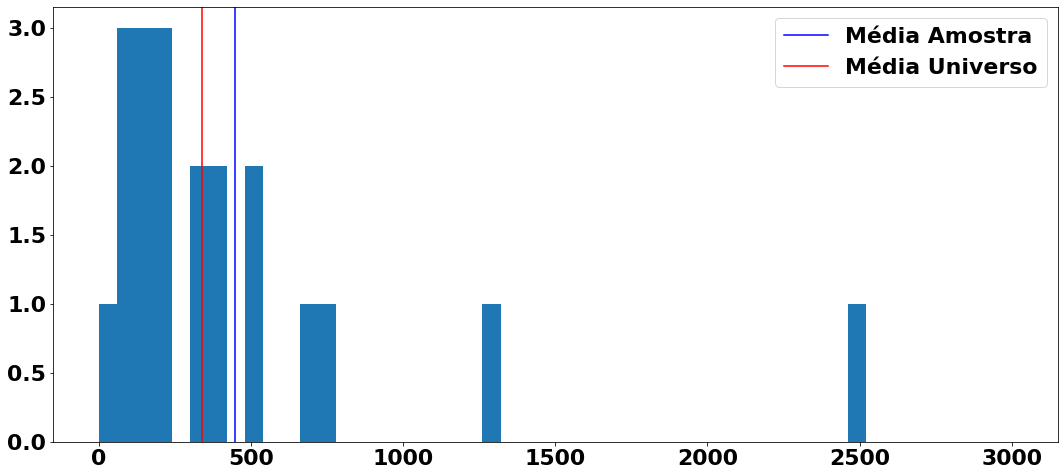

A média da amostra é 449.4 e a média do universo é 340.8


In [ ]:
amostra_decisoes(20)

Em uma amostra de 20 decisões identificamos uma média (449) muito diferente da média do universo de decisões (340).

Se chamarmos a função 'amostra_decisoes()' muitas vezes teremos um fenômeno similar àquele notado com as jogadas de uma moeda. Em algumas das tentativas a média ficará mais próxima da esperada, em outras tentativas a média ficará mais distante. Vamos extrair muitas amostras de decisões e plotar a média de cada amostra no histograma.

In [ ]:
media_universo = stf.dias_decisao.mean()

def muitas_amostras(total_decisoes,total_amostras):
  amostras = []
  for amostra in range(total_amostras):
    amostra = stf.dias_decisao.sample(n=total_decisoes)
    amostras.append(amostra.mean())
  media_medias = np.mean(amostras)
  plt.hist(amostras,bins=50)
  plt.axvline(media_medias,label='Média Amostras',color='blue')
  plt.axvline(media_universo,label='Média Universo',color='red')
  plt.legend()
  plt.show()
  print('A média das médias é',round(media_medias,1),'e a média do universo é',round(media_universo,1))

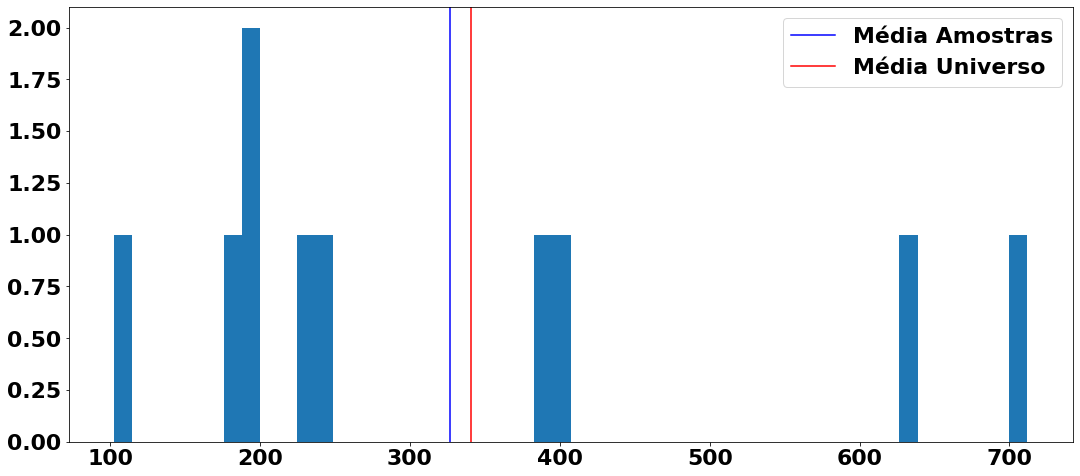

A média das médias é 326.9 e a média do universo é 340.8


In [ ]:
muitas_amostras(10,10)

Cada amostra de 10 decisões pode ter a média de dias até a decisão calculada. Esses são os valores plotados no histograma. 2 das amostras tiveram média de dias até decisão logo abaixo de 200. 1 amostra teve média de dias até a decisão na faixa de 700 dias. 

A aleatoriedade significa que a média de uma amostra pode ser muito diferente da média de outra amostra, muito embora ambas tenham sido extraídas do mesmo universo.

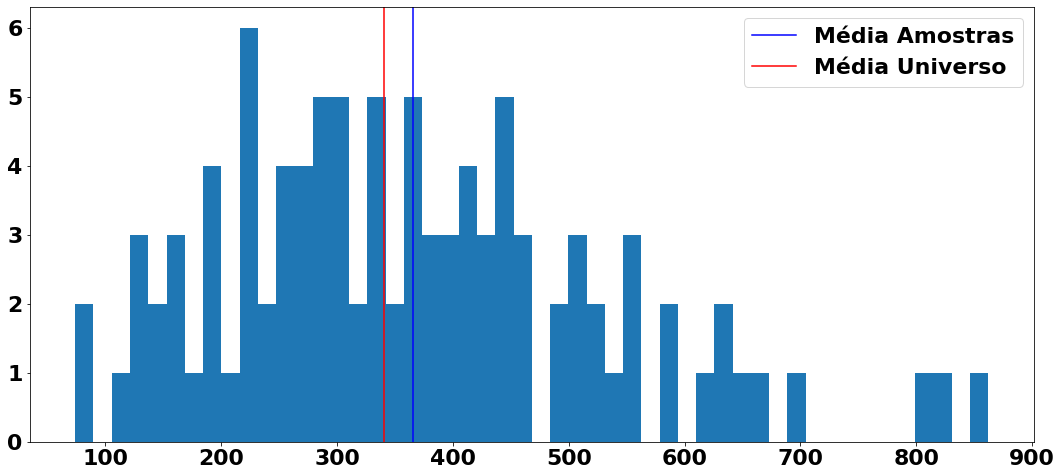

A média das médias é 365.2 e a média do universo é 340.8


In [ ]:
muitas_amostras(10,100)

Com um número maior de amostras já é possível perceber um padrão no histograma. Um número maior delas teve a média perto do centro da distribuição e os extremos - médias de 100 dias ou médias de 800 dias - concentram um número menor das amostras.

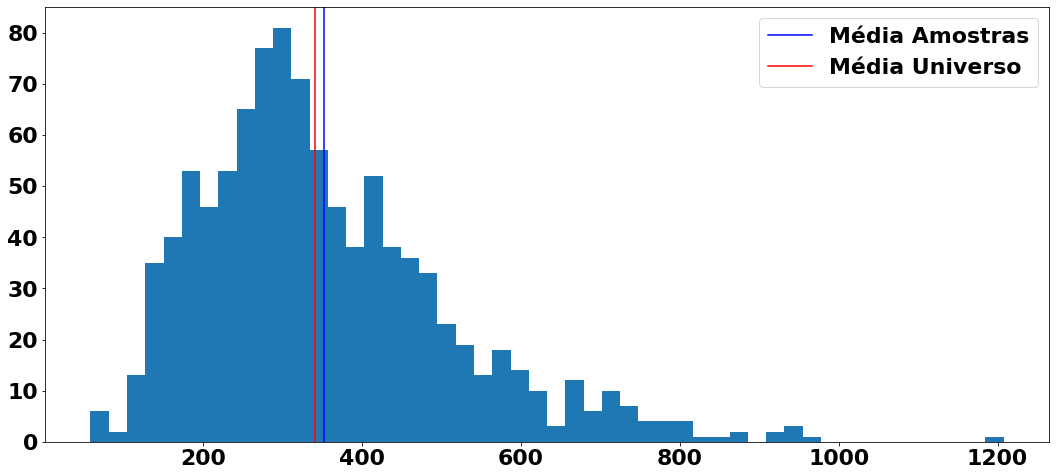

A média das médias é 351.8 e a média do universo é 340.8


In [ ]:
muitas_amostras(10,1000)

Sabemos que no universo de decisões temos muitas outliers em termos do tempo em dias - acima de 4 mil dias. Uma amostra de 10 decisões é mais suscetível a esses outliers e por isso vemos um número maior de amostras no último gráfico com a média bem acima da média das amostras. 

Vamos aumentar o tamanho de cada amostra para 50 decisões.

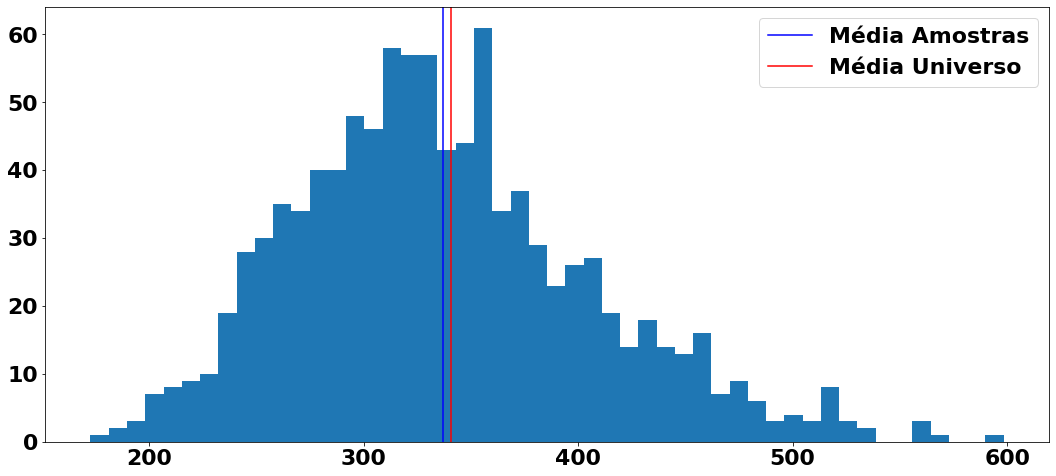

A média das médias é 337.2 e a média do universo é 340.8


In [ ]:
muitas_amostras(50,1000)

Mantivemos o número de amostras - 1000, mas aumentamos o tamanho de cada amostra. Agora nenhuma amostra teve média maior do que 600 dias. Compare com os resultados plotados no gráfico anterior.

Com 1000 amostras a média das médias está em 337 dias, muito próxima da médida do universo, que é de 340 dias.

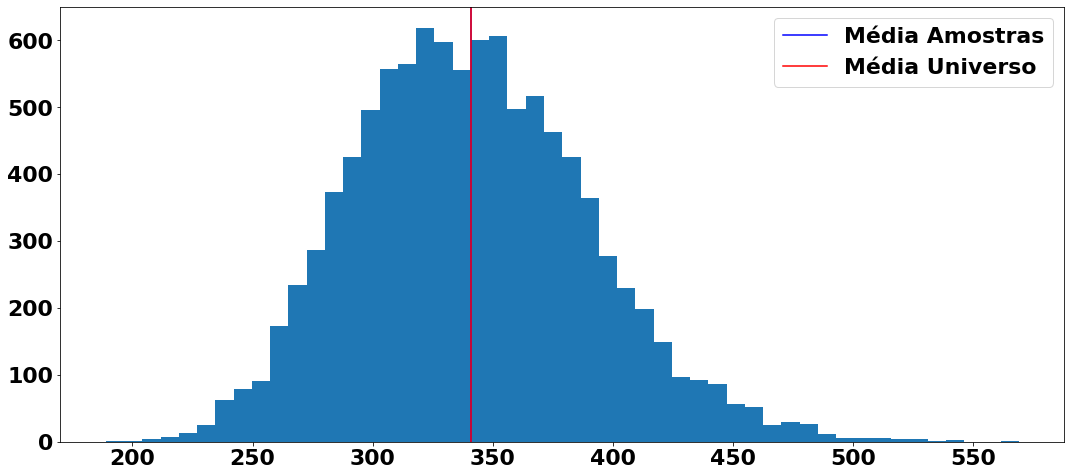

A média das médias é 341.1 e a média do universo é 340.8


In [ ]:
muitas_amostras(100,10000)

Quando extraímos 10.000 amostras aleatórias o resultado é que a média das suas médias fica quase exatamente igual à média do universo. 

A distribuição das médias de cada amostra respeitará um curva normal quando o número de amostras for alto o suficiente.

A distribuição da *frequência* das médias das amostras pode ser também representada como uma distribuição da *proporção* ou *probabilidade* de a média de uma amostra ficar em cada faixa da distribuição.

In [ ]:
media_universo = stf.dias_decisao.mean()

def probabilidade_amostras(total_decisoes,total_amostras):
  plt.rcParams["figure.figsize"] = (22, 11)
  font = {'weight':'bold','size': 10}
  matplotlib.rc('font', **font)
  amostras = []
  for amostra in range(total_amostras):
    amostra = stf.dias_decisao.sample(n=total_decisoes)
    amostras.append(amostra.mean())
  media_medias = np.mean(amostras)
  desvio = np.std(amostras)
  a,b,barras = plt.hist(amostras,bins=50,color='blue',density=True)
  plt.axvspan(media_medias-desvio,media_medias+desvio,alpha=0.6,color='blue',label='1 desvio padrão = 68%')
  plt.axvspan(media_medias-2*desvio,media_medias+2*desvio,alpha=0.4,color='blue',label='2 desvios padrão = 95%')
  plt.axvspan(media_medias-3*desvio,media_medias+3*desvio,alpha=0.2,color='blue',label='3 desvios padrão = 99%')
  plt.axvline(media_medias,label='Média Amostras',color='orange')
  plt.axvline(media_universo,label='Média Universo',color='red')
  plt.legend()
  plt.show()
  print('O desvio padrão das médias é',round(desvio,1),'; a média das médias é',round(media_medias,1),'e a média do universo é',round(media_universo,1))

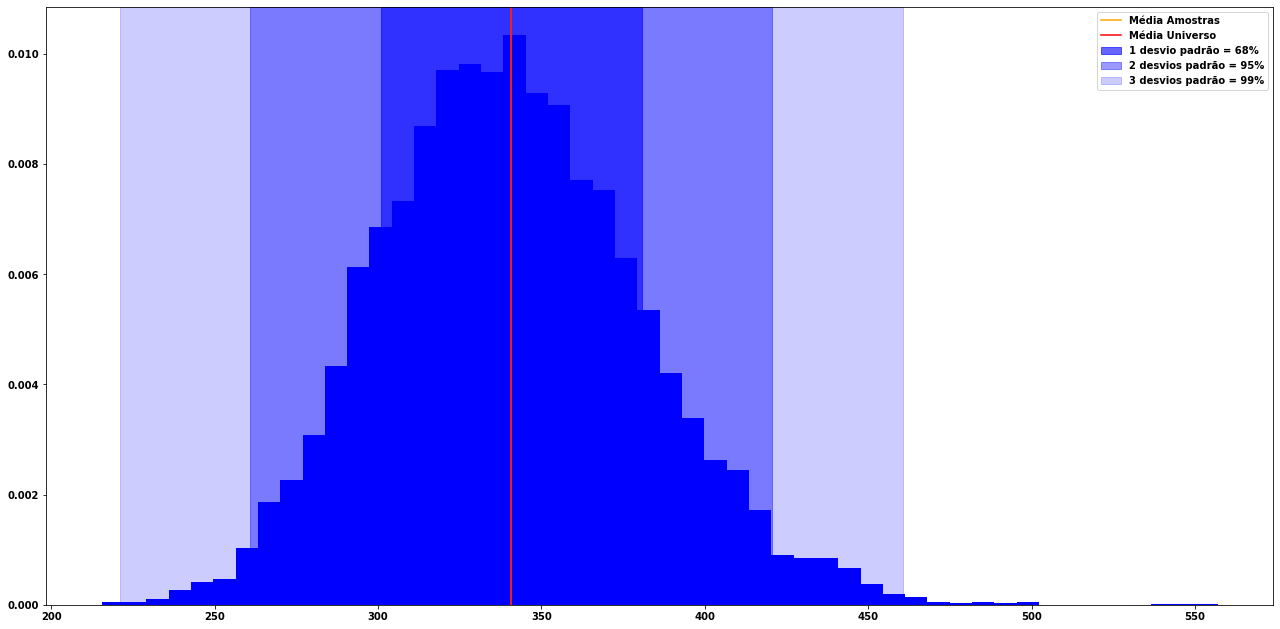

O desvio padrão das médias é 40.0 ; a média das médias é 340.8 e a média do universo é 340.8


In [ ]:
probabilidade_amostras(150,10000)

Considere o desvio padrão das médias como 40.

Imagine o seguinte cenário. O presidente do STF afirma que entre 1991 e 2013 as decisões colegiadas levaram em média 340 dias. 

Extraímos uma amostra de 100 decisões nas quais a média de dias até a decisão é de 461 dias. Qual a probabilidade de a afirmação do presidente do STF ser verdadeira? 

A média dessa amostra estaria mais de 3 desvios padrão acima da média do universo.

461 - 340 = 121

121 / 40 = 3.025. 

Sabemos que a área da distribuição que está a até 3 desvios da média equivale a 99%. Logo, diante de uma amostra tirada com média de 461 dias, a probabilidade de a média divulgada pelo presidente do STF ser precisa  é menor do que 1%. 

Nesse exemplo, o desvio padrão das médias na distribuição de 10.000 amostras havia sido calculado com base no que observamos do resultado da simulação. A simulação nem sempre será possível e, de regra, não teremos de antemão a média do universo. 

Teremos normalmente uma amostra extraída aleatoriamente do universo, para a qual podemos calcular a média e o desvio padrão. Podemos inferir o desvio padrão.

In [ ]:
amostra = stf.dias_decisao.sample(n=100)
desvio = amostra.std()
media = amostra.mean()
print(desvio)
print(media)

433.8202247172639
353.65


Extraímos uma amostra de 100 decisões para as quais a média de dias é 354. Sabemos que há uma margem de erro para essa média. Ou seja, a média da população de decisões provavelmente não é exatamente 354 dias. Mas como calcular a margem de erro?

**Fazemos isso usando o desvio padrão e o tamanho da amostra.** 

**Note que para determinar a margem de erro o tamanho da população é irrelevante.**

O desvio padrão do tempo em dias é 434. Podemos calcular o desvio padrão de uma distribuição de muitas médias.

$σ$ da média = $σ / \sqrt{N}$

Ocorre que normalmente não teremos σ - desvio padrão da população. Teremos apenas o desvio padrão da amostra concreta colhida, s. Devemos presumir que o desvio padrão da amostra é ligeiramente maior do que aquele da população, portanto a fórmula é corrigida para:

$s$ da média = $s / \sqrt{N-1}$


Para uma amostra de 100 decisões com um desvio de 434 dias, temos: 

In [ ]:
erro_padrao = 434/(100-1)**0.5
print(erro_padrao)

43.6186411822498


Chegamos a 43.6 dias de desvio padrão da distribuição das médias. Isso significa que se fossem colhidas milhares de amostras, 68% das médias de dias dessas amostras ficariam entre 434 - 43.6 (um desvio padrão), na ponta inferior, e 434 + 43.6 (um desvio padrão), na ponta superior. 

In [ ]:
print(media-erro_padrao)
print(media+erro_padrao)

310.0313588177502
397.2686411822498


Ou seja, há 68% de chance de que a média de dias no universo seja um valor entre 310 e 397. 

Nesse exemplo, o intervalo de confiança é de 68%. Sabemos que o intervalo de confiança tradicionalmente usado é de 95%. Sabemos também que 95% das observações de uma distribuição normal ficam entre 

média - 1.96 * desvio padrão

na ponta inferior, e 

média + 1.96 * desvio padrão

na ponta superior. Nos casos em que o tamanho da amostra é inferior a 30 observações o valor não é exatamente 1.96 e sim algo ligeiramente maior. Podemos presumir que nossas amostras serão sempre de 30 ou mais observações e adotar 1.96 desvios padrão como a distância abaixo e acima da média que abrange 95% das ocorrências.

In [ ]:
print(erro_padrao*1.96)
print(media-erro_padrao*1.96)
print(media+erro_padrao*1.96)

85.49253671720962
268.15746328279033
439.1425367172096


Há 95% de chance de a média em dias da população ser um valor entre 268 e 439 dias. Ou podemos dizer que a média da população é estimada em 354 dias com margem de erro de 85 dias em um intervalo de confiança de 95%.

Podemos testar o resultado obtido com a amostra diante do universo das decisões na base:

In [ ]:
stf.dias_decisao.mean()

340.81763281123847

Vamos seguir os mesmos passos para calcular a margem de erro usando uma nova base simulada de contratos elaborados por um escritório de advocacia para diferentes empresas clientes. Alguns desses contratos continuam válidos, alguns foram objeto de litígio e alguns foram rescindidos. 

In [ ]:
clientes = np.random.choice(['Vivo','Azul','GM','Fiat','Nestlé'],size=5000,p=[0.2,0.1,0.3,0.25,0.15])
status_contratos = np.random.choice(['ativo','litígio','rescindido'],size=5000,p=[0.75,0.15,0.1])
valores = np.random.normal(100000,25000,5000).round(0)
horas = np.random.normal(20,5,5000).round(0)

In [ ]:
contratos = {'cliente':clientes,'status':status_contratos,'valor_contrato':valores,'horas_trabalhadas':horas}
contratos = pd.DataFrame.from_dict(contratos)
contratos.head(20)

,cliente,status,valor_contrato,horas_trabalhadas
0,Fiat,litígio,145987.0,25.0
1,GM,litígio,125165.0,23.0
2,Vivo,ativo,111967.0,34.0
3,Nestlé,ativo,112167.0,23.0
4,Fiat,ativo,77656.0,20.0
5,Vivo,rescindido,142140.0,18.0
6,Fiat,ativo,131359.0,15.0
7,GM,rescindido,82152.0,29.0
8,Vivo,ativo,109707.0,18.0
9,Azul,ativo,71643.0,33.0


In [ ]:
tamanho_amostra = 30
amostra = contratos.valor_contrato.sample(n=tamanho_amostra)
media_amostra = amostra.mean()
desvio_amostra = amostra.std()
print(desvio_amostra)

25271.663464323494


Extraímos uma amostra de 30 contratos para os quais o desvio padrão do valor do contrato é 25272 reais. Podemos calcular o desvio padrão de uma distribuição de muitas médias de valor de contrato.

$s$ média = $s$ / $\sqrt{N-1}$

Para uma amostra de 30 decisões com um desvio de 25272 reais, temos:

In [ ]:
desvio_das_medias = desvio_amostra/((tamanho_amostra-1)**0.5)

Esse valor é o erro padrão.

Feito o cálculo do desvio padrão em uma distribuição (hipotética) de muitas médias de valor de contrato, podemos determinar os valores de início e fim de um recorte de 95% delas:

In [ ]:
margem_de_erro_intervalo_95 = desvio_das_medias * 1.96 

In [ ]:
print('A média dos valores de contrato na amostra é de',round(media_amostra,0),'com margem de erro de',round(margem_de_erro_intervalo_95,0))

A média dos valores de contrato na amostra é de 103182.0 com margem de erro de 9198.0


In [ ]:
print('Isso significa que há 95% de chance de a média no universo de contratos ser entre',round(media_amostra-margem_de_erro_intervalo_95,0),'e',round(media_amostra+margem_de_erro_intervalo_95,0))

Isso significa que há 95% de chance de a média no universo de contratos ser entre 93984.0 e 112380.0


Temos então a média da amostra com a respectiva margem de erro. Será que a média do valor do universo de contratos está dentro dessa margem?

In [ ]:
contratos.valor_contrato.mean()

99290.2184

A média da população está dentro de nossa margem de erro?

Vamos repetir todos os mesmos passos, porém agora para uma amostra de 50 contratos que foram rescindidos.

In [ ]:
tamanho_amostra = 50
amostra = contratos.valor_contrato[contratos.status == 'rescindido'].sample(n=tamanho_amostra)
media_amostra = amostra.mean()
desvio_amostra = amostra.std()
print(desvio_amostra)

28295.85825212025


Extraímos uma amostra de 50 contratos rescindidos para os quais o desvio padrão do valor do contrato é 28296 reais. Podemos calcular o desvio padrão de uma distribuição de muitas médias de valor de contrato rescindido.

$s$ média = $s$ / $\sqrt{N-1}$

Para uma amostra de 50 contratos rescindidos com um desvio de 28296 reais, temos:

In [ ]:
desvio_das_medias = desvio_amostra/((tamanho_amostra-1)**0.5)

Feito o cálculo do desvio padrão em uma distribuição (hipotética) de muitas médias de valor de contrato rescindido, podemos determinar os valores de início e fim de um recorte de 95% delas:

In [ ]:
margem_de_erro_intervalo_95 = desvio_das_medias * 1.96 

In [ ]:
print('A média dos valores de contrato rescindido na amostra é de',round(media_amostra,0),'com margem de erro de',round(margem_de_erro_intervalo_95,0))

A média dos valores de contrato rescindido na amostra é de 96248.0 com margem de erro de 7923.0


In [ ]:
print('Isso significa que há 95% de chance de a média no universo de contratos rescindidos ser entre',round(media_amostra-margem_de_erro_intervalo_95,0),'e',round(media_amostra+margem_de_erro_intervalo_95,0))

Isso significa que há 95% de chance de a média no universo de contratos rescindidos ser entre 88325.0 e 104171.0


In [ ]:
contratos.valor_contrato[contratos.status=='rescindido'].mean()

97780.61349693252

A média de valor em reais dos contratos rescindidos na população está dentro da margem de erro da nossa amostra?

Até aqui extraímos amostras de valores de uma variável numérica e calculamos a média desses valores da amostra com uma margem de erro. 

Podemos também extrair amostras de valores de uma variável categórica e calcular a margem de erro da proporção.

In [ ]:
tamanho_amostra = 50
amostra = contratos.status.sample(n=tamanho_amostra)
amostra.value_counts(normalize=True)

ativo         0.82
litígio       0.14
rescindido    0.04
Name: status, dtype: float64

Queremos saber a proporção dos 5000 contratos que acabaram sendo objeto de litígio. O escritório de advocacia precisa monitorar com que frequência os contratos que elabora para seus clientes são questionados judicialmente.

Para determinar essa proporção, em vez que abrir as informações para cada um dos 5000 contratos, o que levaria muito tempo, a estagiária abre a informação de apenas 50 dos contratos, escolhidos aleatoriamente. Nessa amostra, 14% dos contratos foram litigados. 

O erro padrão da proporção de uma amostra é calculado segundo a seguinte fórmula:

$s$ = $\sqrt{P(1-P)/N}$

Nesse caso, temos

$s$ = $\sqrt{0.14 * (1-0.14) / 50}$


In [ ]:
((0.14 * (1-0.14))/50)**0.5

0.04907137658554119

O erro padrão da proporção de contratos rescindidos na amostra é de 0.05. Podemos calcular a margem de erro para um intervalo de confiança de 95%:

In [ ]:
print('Há 95% de chance de a proporção de contratos litigados no universo ser entre',round(0.14-(0.05*1.96),3),'e',round(0.14+(0.05*1.96),3))

Há 95% de chance de a proporção de contratos litigados no universo ser entre 0.042 e 0.238


Podemos testar o resultado do dado obtido a partir da amostra checando a proporção no universo:

In [ ]:
contratos.status.value_counts(normalize=True)

ativo         0.7556
litígio       0.1466
rescindido    0.0978
Name: status, dtype: float64

A margem de erro será tanto menor quanto maior o tamanho da amostra. Ao receber a informação calculada pela estagiária, a sócia ficou curiosa sobre outros aspectos dos 5000 mil contratos elaborados pelo escritório no passado recente e decidiu pedir outro dado. Qual a parcela desses contratos realizados para uma das maiores clientes do escritório, a General Motors. 

A estagiária novamente consulta as informações de apenas uma parte pequena do total de contratos, escolhendo aleatoriamente. Ela decide analisar 70 contratos.

In [ ]:
tamanho_amostra = 70
amostra = contratos.cliente.sample(n=tamanho_amostra)
amostra.value_counts(normalize=True).round(2)

GM        0.33
Fiat      0.24
Nestlé    0.17
Vivo      0.17
Azul      0.09
Name: cliente, dtype: float64

Na amostra a proporção de contratos elaboradas para a cliente GM é de 0.33. 

Nesse caso, o cálculo do erro padrão é feito segundo a mesma fórmula:

$s$ = $\sqrt{0.33 * (1-0.33) / 70}$

In [ ]:
erro_padrao = ((0.33 * (1-0.33))/70)**0.5
erro_padrao = round(erro_padrao,3)
print(erro_padrao)

0.056


Com erro padrão de 0.056, podemos calcular a margem de erro. 

In [ ]:
print('Há 95% de chance de a proporção de contratos da cliente GM no universo ser entre',round(0.33-(erro_padrao*1.96),3),'e',round(0.33+(erro_padrao*1.96),3))

Há 95% de chance de a proporção de contratos da cliente GM no universo ser entre 0.22 e 0.44


Podemos testar novamente o resultado obtido por nossa amostra comparando com a propoção no universo dos contratos.

In [ ]:
contratos.cliente.value_counts(normalize=True)

GM        0.2956
Fiat      0.2520
Vivo      0.2002
Nestlé    0.1498
Azul      0.1024
Name: cliente, dtype: float64

## Probabilidade e curva normal <a class="anchor" id="second-bullet"></a>

Sabemos que uma decisão judicial pode ser favorável à parte autora, à parte ré ou parcialmente favorável à parte autora. Essas três opções podem ter sua probabilidade baseada em matemática teórica fixada em 1/3 ou 0.33 cada. 

Para cada órgão judicial, no entanto, podemos determinar a probabilidade a partir de observação sistemática. 61 mil decisões colegiadas ao longo de 22 anos de atuação do STF são uma boa base de observação sistemática para determinar a probabilidade das três opções de resultado. 

In [ ]:
stf.decisao.value_counts(normalize=True).round(decimals=2)

procedencia        0.51
negativa_merito    0.19
proced_parcial     0.18
negativa_adm       0.12
admissao           0.00
Name: decisao, dtype: float64

A partir dessa observação, temos as seguintes proporções de decisões favoráveis à parte ré: negativa de admissão com 0.12 e negativa de mérito com 0.19. 

Nessa base de dados, a decisão que nega admissão e a decisão de nega o pedido no mérito são *mutuamente excludentes* - ou seja, uma mesma decisão não pode ser ao mesmo tempo negativa de admissão e negativa de mérito. Isso significa que pela regra da soma a probabilidade de uma decisão favorável à parte ré é

**P(neg_merito ou neg_admissao) = P(neg_merito) + P(neg_admissao)**

A probabilidade de uma decisão favorável à parte ré é de 0.12 + 0.19 = 0.31 ou 31%. 

Usando a mesma lógica, podemos calcular a probabilidade de uma decisão que não é favorável à parte autora. Trata-se da regra complementar de probabilidade: 

**P(favorável parte autora) = 1 - P(desfavorável ou parcialmente favorável parte autora)**

Sabemos que a probabilidade de uma decisão desfavorável à parte autora é de 0.31. A probabilidade observada de uma decisão parcialmente favorável à parte autora é de 0.18. 

P(favorável parte autora) = 1 - (0.31 + 0.18)

P(favorável parte autora) = 1 - 0.49

P(favorável parte autora) = 0.51

Se pensarmos que a decisão tomada pelo STF em uma semana e a decisão tomada na semana seguinte, em outro processo, são *resultados independentes*, então podemos calcular a probabilidade de duas decisões seguidas favoráveis à parte autora.

**P(decisão A e B favoráveis parte autora) = P(A favorável) * P(B favorável)**

P(decisão A e B favoráveis parte autora) = 0.51 * 0.51

P(decisão A e B favoráveis parte autora) = 0.26

Logo, a probabilidade de o STF decidir duas vezes seguidas, em processos diferentes, de forma favorável à parte autora, é de 0.26 ou 26%. 

Vamos repetir essas mesmas três formulações usando a probabilidade de o STF decidir em diferentes classes processuais, conforme observação sistemática.


In [ ]:
stf.sig_classe_process.value_counts(normalize=True).round(decimals=3)

RE      0.701
HC      0.212
RHC     0.021
IF      0.012
MS      0.012
ADI     0.009
RMS     0.008
Rcl     0.007
AI      0.003
AO      0.003
AC      0.003
MI      0.002
Inq     0.002
Ext     0.001
CC      0.001
AR      0.001
SEC     0.001
ACO     0.001
Pet     0.000
AP      0.000
PSV     0.000
SS      0.000
ADPF    0.000
ADC     0.000
RvC     0.000
ARE     0.000
AOE     0.000
CR      0.000
Name: sig_classe_process, dtype: float64

Ao longo de 22 anos, a observação sistemática permite afirmar que a chance de qualquer órgão colegiado do STF decidir um Recurso Extraordinário é de 70,1%. A probabilidade de qualquer órgão colegiado decidir uma Ação Direta de Inconstitucionalidade é de 0.009 ou 0.9%. 

Vamos verificar se a pauta do plenário segue padrões similares.

In [ ]:
stf.sig_classe_process[stf.orgao == 'plenario'].value_counts(normalize=True).round(decimals=3)

IF      0.204
MS      0.178
ADI     0.149
RE      0.115
Rcl     0.112
HC      0.059
AO      0.034
MI      0.033
Inq     0.027
CC      0.013
AR      0.011
SEC     0.011
ACO     0.010
AC      0.008
Ext     0.007
AP      0.005
Pet     0.005
RHC     0.005
PSV     0.004
RMS     0.003
SS      0.002
ADPF    0.001
ADC     0.001
RvC     0.001
CR      0.000
AOE     0.000
AI      0.000
Name: sig_classe_process, dtype: float64

Considerando apenas as decisões do plenário, as chances de uma decisão em ADI são muito maiores. A probabilidade é de 0.149 ou 14,9%. 

Qual é a probabilidade de o plenário decidir uma ação do controle concentrado?

**P(concentrado) = P(ADI) + P(ADPF) + P(ADC) + P(ADO)**

P(concentrado) = 0.149 + 0.001 + 0.001 + 0.000

P(concentrado) = 0.151

Qual a probabilidade de o plenário decidir um processo que não é um habeas corpus?

**P(não HC) = 1 - P(HC)**

P(não HC) = 1 - 0.059

P(não HC) = 1 - 0.941

E nas turmas?

In [ ]:
stf.sig_classe_process[stf.orgao != 'plenario'].value_counts(normalize=True).round(decimals=3)

RE     0.738
HC     0.222
RHC    0.022
RMS    0.008
AI     0.004
AC     0.002
AO     0.001
MS     0.001
Ext    0.000
Rcl    0.000
Pet    0.000
ARE    0.000
Name: sig_classe_process, dtype: float64

Nas turmas a probabilidade de uma decisão ser em HC é de 0.222. Portanto, a probabilidade de uma decisão não ser em HC é de 0.778.

Existe um mito de que o STF decide majoritariamente ações no controle concentrado de constitucionalidade. Vimos que na verdade o plenário tem uma probabilidade de 0.151 ou 15,1% de chances de decidir um processo nessa competência. 

Qual a chance de que três decisões seguidas do plenário sejam no controle concentrado?

**P(3 controle concentrado) = P(concentrado) * P(concentrado) * P(concentrado)**

P(3 controle concentrado) = 0.151 * 0.151 * 0.151

P(3 controle concentrado) = 0.003

Existe 0,3% de chances de o plenário decidir três ações do controle concentrado em sequência. Podemos dizer que essa probabilidade é aquela baseada na teoria da probabilidade. 

É possível calcular a probabilidade de um evento A uma vez que o evento B tenha acontecido. Ou seja, qual é a probabilidade de A dado que B aconteceu? 

Exemplos:
1) Qual é a probabilidade de uma decisão de procedência dado que o relator sorteado é o Min. Marco Aurélio?

2) Qual é a probabilidade de uma decisão de negativa de mérito dado que a relatora sorteada é a Min. Carmén Lúcia?

Essa regra é expressada da seguinte forma:

**P(A | B) = P(A e também B) / P(B)**

No exemplo 1, precisamos saber duas coisas: Qual a probabilidade de uma decisão ser de procedência e também da relatoria do Min. Marco Aurélio?





In [ ]:
stf.groupby(['decisao','ministro']).count()

sig_classe_process  \
decisao     ministro                                                       
admissao    MIN. CARLOS VELLOSO                                        2   
            MIN. CEZAR PELUSO                                          1   
            MIN. GILMAR MENDES                                         1   
            MIN. ILMAR GALVÃO                                          1   
            MIN. MARCO AURÉLIO                                         1   
...                                                                  ...   
procedencia MIN. SEPÚLVEDA PERTENCE                                 2352   
            MIN. SYDNEY SANCHES                                     2978   
            MIN. TEORI ZAVASCKI                                       24   
            MINISTRO PRESIDENTE                                        8   
            PRESIDENTE DA COMISSÃO DE JURISPRUDÊNCIA                  12   

                                                      num_processo  \
decisao     ministro                                                 
admissao    MIN. CARLOS VELLOSO                                  2   
            MIN. CEZAR PELUSO                                    1   
            MIN. GILMAR MENDES                                   1   
            MIN. ILMAR GALVÃO                                    1   
            MIN. MARCO AURÉLIO                                   1   
...                                                            ...   
procedencia MIN. SEPÚLVEDA PERTENCE                           2352   
            MIN. SYDNEY SANCHES                               2978   
            MIN. TEORI ZAVASCKI                                 24   
            MINISTRO PRESIDENTE                                  8   
            PRESIDENTE DA COMISSÃO DE JURISPRUDÊNCIA            12   

                                                      data_decisao  \
decisao     ministro                                                 
admissao    MIN. CARLOS VELLOSO                                  2   
            MIN. CEZAR PELUSO                                    1   
            MIN. GILMAR MENDES                                   1   
            MIN. ILMAR GALVÃO                                    1   
            MIN. MARCO AURÉLIO                                   1   
...                                                            ...   
procedencia MIN. SEPÚLVEDA PERTENCE                           2352   
            MIN. SYDNEY SANCHES                               2978   
            MIN. TEORI ZAVASCKI                                 24   
            MINISTRO PRESIDENTE                                  8   
            PRESIDENTE DA COMISSÃO DE JURISPRUDÊNCIA            12   

                                                      ano_decisao  orgao  \
decisao     ministro                                                       
admissao    MIN. CARLOS VELLOSO                                 2      2   
            MIN. CEZAR PELUSO                                   1      1   
            MIN. GILMAR MENDES                                  1      1   
            MIN. ILMAR GALVÃO                                   1      1   
            MIN. MARCO AURÉLIO                                  1      1   
...                                                           ...    ...   
procedencia MIN. SEPÚLVEDA PERTENCE                          2352   2352   
            MIN. SYDNEY SANCHES                              2978   2978   
            MIN. TEORI ZAVASCKI                                24     24   
            MINISTRO PRESIDENTE                                 8      8   
            PRESIDENTE DA COMISSÃO DE JURISPRUDÊNCIA           12     12   

                                                      unanimidade  assunto  \
decisao     ministro                                                         
admissao    MIN. CARLOS VELLOSO                                 2        2   
            MIN. CEZ

Usando o método 'groupby()' e o critério 'count()' podemos identificar 3313 decisões que são de procedência e que são de relatoria do Min. Marco Aurélio. 
A probabilidade é obtida dividindo essa frequência pelo total de todas as observações:

In [ ]:
3313/len(stf)

0.053495882447925074

Já temos o primeiro valor necessário para fazer o cálculo. Agora precisamos da probabilidade de que o relator sorteado seja o Min. Marco Aurélio.

In [ ]:
stf.ministro.value_counts()/len(stf)

MIN. MOREIRA ALVES                          0.126982
MIN. ILMAR GALVÃO                           0.092492
MIN. MARCO AURÉLIO                          0.092249
MIN. CARLOS VELLOSO                         0.078266
MIN. NÉRI DA SILVEIRA                       0.072808
MIN. SYDNEY SANCHES                         0.064815
MIN. CELSO DE MELLO                         0.059600
MIN. SEPÚLVEDA PERTENCE                     0.055676
MIN. CEZAR PELUSO                           0.048296
MIN. MAURÍCIO CORRÊA                        0.046472
MIN. OCTAVIO GALLOTTI                       0.041369
MIN. FRANCISCO REZEK                        0.035863
MIN. NELSON JOBIM                           0.024657
MIN. PAULO BROSSARD                         0.022848
MIN. RICARDO LEWANDOWSKI                    0.016987
MIN. GILMAR MENDES                          0.016874
MIN. CÁRMEN LÚCIA                           0.015598
MIN. ELLEN GRACIE                           0.015178
MIN. AYRES BRITTO                           0.

Essa probabilidade é de 0.09.

Então temos:

P(Decisão procedente dado que relator Min. MA) = P(Decisão procedente e também do Min. MA) / P(Relatoria Min. MA)

P(Decisão procedente dado que relator Min. MA) = 0.05 / 0.09

P(Decisão procedente dado que relator Min. MA) = 0.55

O segundo exemplo é similar: Qual é a probabilidade de uma decisão de negativa de mérito dado que a relatora sorteada é a Min. Carmén Lúcia? Podemos obter as duas probabilidades necessárias para o cálculo por um caminho diferente e mais parecido com a própria fórmula.

In [ ]:
len(stf[(stf.decisao == 'negativa_merito')&(stf.ministro == 'MIN. CÁRMEN LÚCIA')])/len(stf)

0.010528015501372518

A probabilidade de uma decisão ser negativa de mérito e também ser de relatoria da Min. Cármen Lúcia é de 0.01.

Podemos calcular a probabilidade de a relatora ser a Min. Cármen Lúcia usando o mesmo caminho:

In [ ]:
len(stf[stf.ministro == 'MIN. CÁRMEN LÚCIA'])/len(stf)

0.015598256095591798

Com essas duas probabilidades podemos usar a fórmula:

P(Decisão negativa mérito dado que relatora Min. CL) = P(Decisão negativa mérito e também da Min. CL) / P(Relatoria Min. CL)

P(Decisão negativa mérito dado que relatora Min. CL) = 0.01 / 0.015

P(Decisão negativa mérito dado que relatora Min. CL) = 0.66

Com base na teoria da probabilidade, sabemos que há 50% de chances de uma moeda normal cair com o lado coroa virado para cima ao ser jogada. Mas, ao observarmos algumas poucas jogadas, percebemos que nem sempre o lado coroa cai para cima metade das jogadas. Podemos simular uma jogada de moeda ou sorteio usando a função 'random.choice()' da biblioteca numpy. Ela permite determinar de qual conjunto de opções estamos sorteando, quantos sorteios - nesse caso, quantas vezes a moeda será jogada - e qual a probabilidade para que o resultado seja cada um dos objetos do conjunto.  

['coroa' 'cara' 'cara' 'coroa']


(array([2., 0., 0., 0., 0., 0., 0., 0., 0., 2.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <a list of 10 Patch objects>)

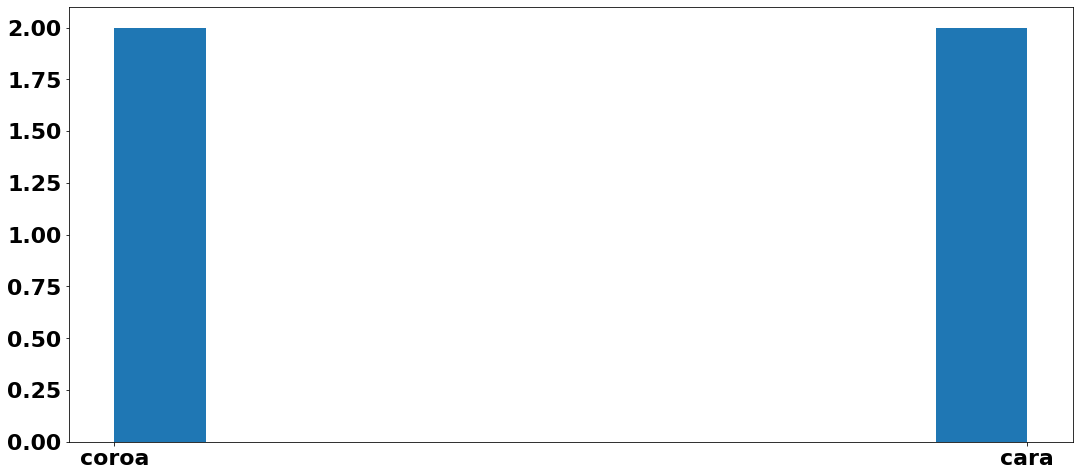

In [ ]:
sorteio = np.random.choice(['cara','coroa'],size=4,p=[0.5,0.5])
print(sorteio)
plt.hist(sorteio)

Ao jogar uma moeda 10 vezes, o esperado era que em metade delas o resultado fosse coroa e na outra metade, cara. Mas no mundo real isso não irá acontecer sempre.

Podemos fazer um for loop similar para testar muitas jogadas de uma moeda.

In [ ]:
def jogadas(total_jogadas,total_observacoes,prob=0.5):
  observacoes = []
  for jogadas in range(total_observacoes):
    sorteio = list(np.random.choice(['cara','coroa'],size=total_jogadas,p=[prob,prob]))
    coroas = sorteio.count('coroa')
    observacoes.append(coroas)
  plt.hist(observacoes,bins=np.arange(total_jogadas+2)-0.5)
  plt.xticks(range(total_jogadas+1))
  plt.xlim([-1,total_jogadas+1])
  plt.show()

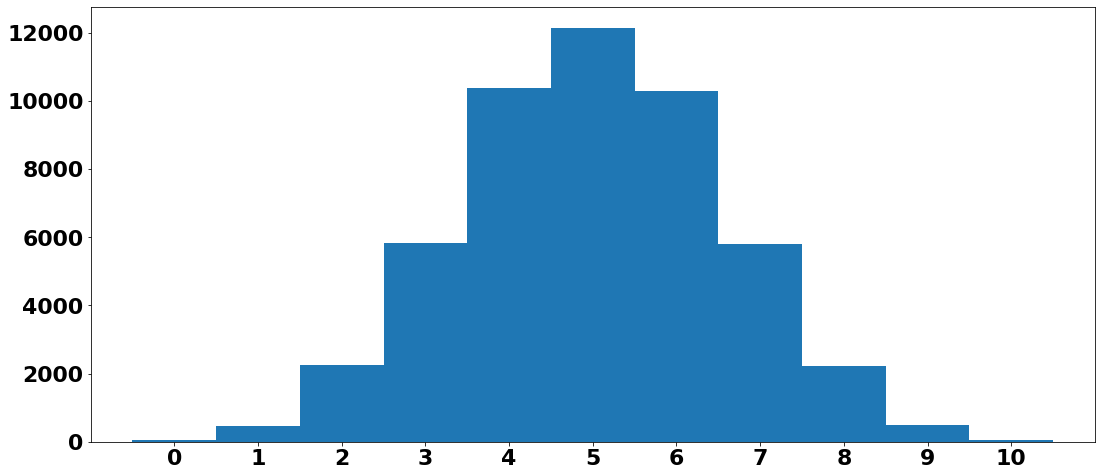

In [ ]:
jogadas(10,50000)

Quando repetimos dez vezes o teste de jogar duas vezes uma moeda, o esperaro é que em 5 dessas vezes tenhamos uma coroa. Nesse exemplo aleatório isso aconteceu 7 das 10 vezes. Também esperávemos que a proporção de resultados coroa-coroa fosse igual à proporção de resultados cara-cara. Isso também não se confirmou. 

Mas note o que acontece quando vamos aumentando o número de testes.

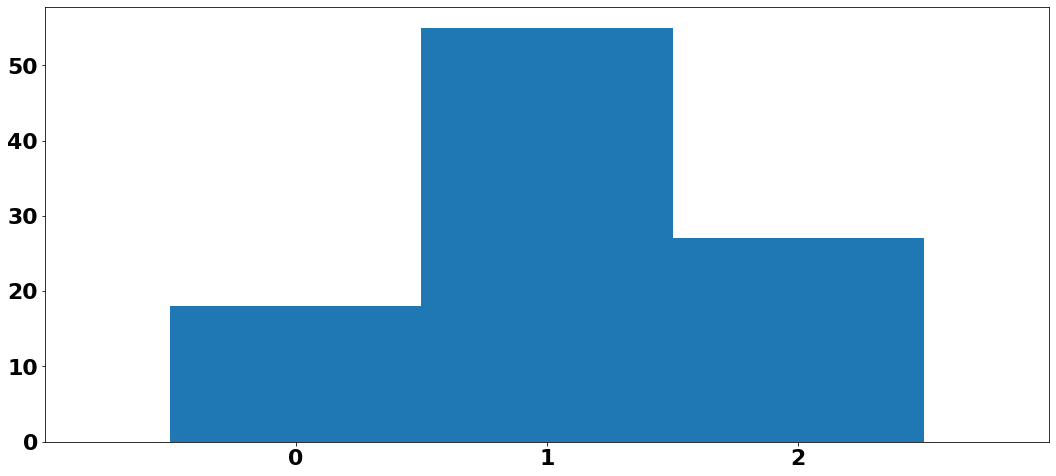

In [ ]:
jogadas(2,100)

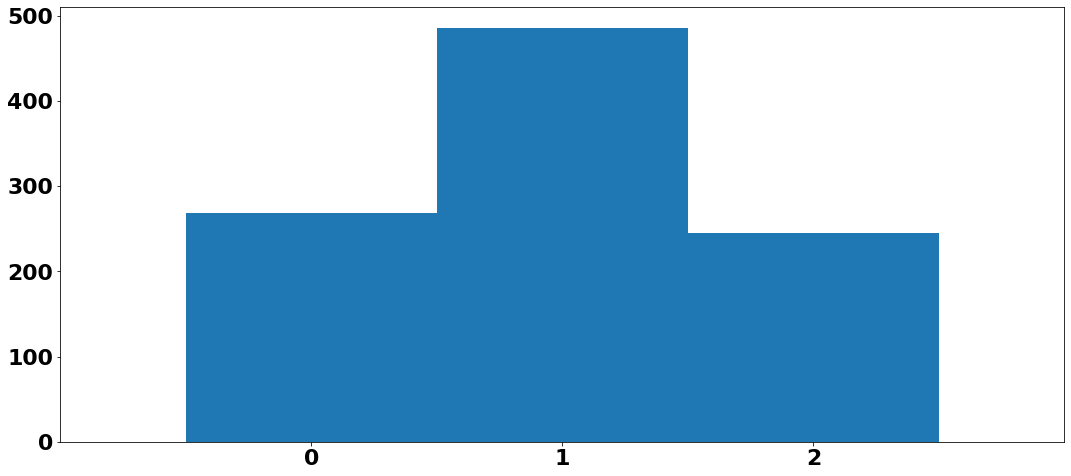

In [ ]:
jogadas(2,1000)

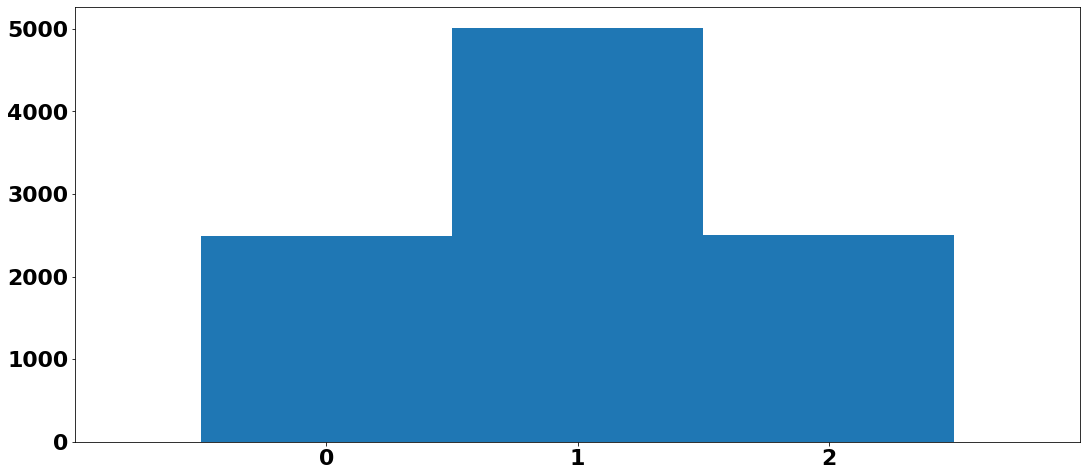

In [ ]:
jogadas(2,10000)

Quando fizemos o teste 10.000 vezes o resultado é quase idêntico ao esperado segundo a teoria! Em 5.000 dos testes tivemos uma coroa e uma cara. Em cerca de 2.500 testes tivemos nenhuma coroa e em outros 2.500 tivemos duas coroas.

Embora só tenhamos 3 valores possíveis no eixo x, é possível perceber que o formato da distribuição se aproxima mais de uma curva normal quanto maior o número de tentativas.

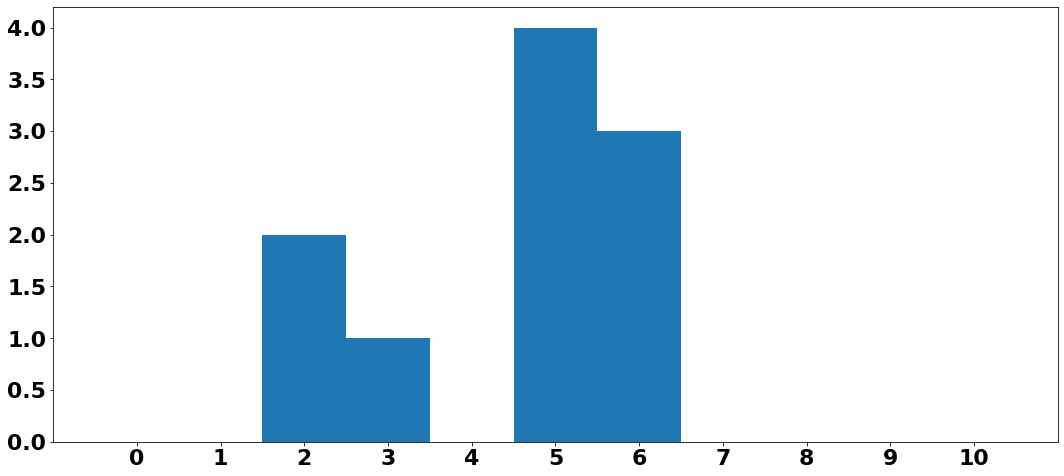

In [ ]:
jogadas(10,10)

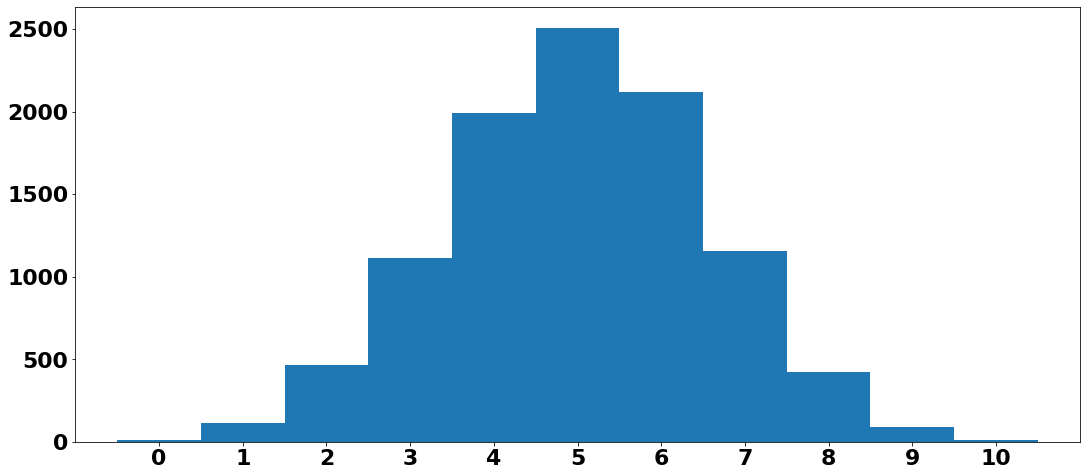

In [ ]:
jogadas(10,10000)

Uma constatação crucial é que **a média da proporção de coroas ao longo de todos os sorteios tende a ser igual à probabilidade teórica de uma moeda dar coroa - 50%. Isso é percebido quando o número de sorteios fica grande o suficiente.**

**Essa é a lei dos grandes números. Ela pode ser provada para qualquer fenômeno jurídico e não apenas jogadas de moeda.**

Com base na teoria da probabilidade, qual a chance de três HCs seguidos serem decididos totalmente em favor do paciente no STF?

In [ ]:
stf.decisao[stf.sig_classe_process == 'HC'].value_counts(normalize=True).round(decimals=2)

negativa_merito    0.61
procedencia        0.23
negativa_adm       0.12
proced_parcial     0.05
Name: decisao, dtype: float64

A probabilidade de um HC ser decidido totalmente em favor do paciente é de 0.23. A probabilidade de três HCs seguidos serem decididos pelo STF em favor do paciente é 

P(3 HCs paciente) = P(HC paciente) * P(HC paciente) * P(HC paciente)

P(3 HCs paciente) = 0.012

Então, na teoria, se o STF decidir três HCs em sequência 100 vezes, em apenas uma dessas vezes os três serão totalmente em favor do paciente. 

Graças às ferramentas da computação, nós podemos realizar esse teste facilmente para determinar o que acontece de fato - expressando aquilo que foi observado em uma distribuição de frequência. Há duas maneiras de fazer isso. Podemos buscar decisões em HC no dataframe de maneira aleatória ou simular um sorteio no qual há 0.23 de probabilidade do resultado de procedência.

Primeiro, vamos buscar decisões em HC no dataframe 'stf' de forma aleatória, em conjuntos de três. O código abaixo sorteio três linhas do dataframe, desde que sejam linhas nas quais a coluna 'sig_classe_process' está preenchida com 'HC'. Dessas três linhas sorteadas, o número delas que é de 'procedencia' é retornado. Esse total pode ser 0, 1, 2 ou 3.

In [ ]:
def amostra_hc(total_decisoes):
  total = 0
  amostra = stf.decisao[stf.sig_classe_process == 'HC'].sample(n=total_decisoes)
  print(amostra)
  for linha in amostra.items():
    if linha[1] == 'procedencia':
      total += 1
  print('O total de decisões de procedência nesse sorteio foi',total) 

In [ ]:
amostra_hc(10)

56184    negativa_merito
26384    negativa_merito
48789    negativa_merito
53569        procedencia
33867    negativa_merito
15667    negativa_merito
52105    negativa_merito
56244     proced_parcial
52666    negativa_merito
13340    negativa_merito
Name: decisao, dtype: object
O total de decisões de procedência nesse sorteio foi 1


Também podemos programar uma simulação de sorteio de decisões em HC no STF usando como probabilidade programada aquela que adotamos como probabilidade teórica de um HC favorável ao paciente: 0.23 ou 23%.

['demais' 'demais' 'demais']


(array([0., 0., 0., 0., 0., 3., 0., 0., 0., 0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <a list of 10 Patch objects>)

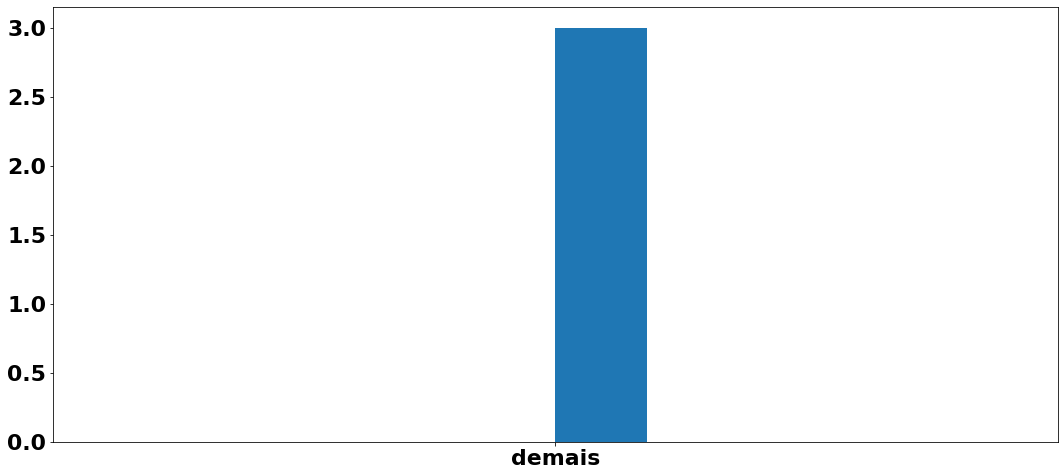

In [ ]:
tres_hcs = np.random.choice(['procedencia','demais'],size=3,p=[0.23,0.77])
print(tres_hcs)
plt.hist(tres_hcs)

Esse código cria de forma aleatória o cenário de três decisões seguidas em HC. 

Supostamente, se rodarmos esse código 100 vezes, em uma delas teremos o gráfico com a barra 'procedencia' alcançando 3 unidades. Podemos fazer isso facilmente com um for loop. Tecnicamente, um HC decidido em favor do paciente é um HC concedido. Mas vamos usar a terminologia genérica para decisões no STF em geral, que é de procedência ou não procedência. 

In [ ]:
def hcs(total_decisoes,total_observacoes,prob_procedencia=0.23):
  observacoes = []
  for decisoes in range(total_observacoes):
    teste = list(np.random.choice(['procedencia','nao procedencia'],size=total_decisoes,p=[prob_procedencia,1-prob_procedencia]))
    procedencias = teste.count('procedencia')
    observacoes.append(procedencias)
  plt.hist(observacoes,bins=np.arange(total_decisoes+2)-0.5)
  plt.xticks(range(total_decisoes+1))
  plt.xlim([-1,total_decisoes+1])
  plt.show()


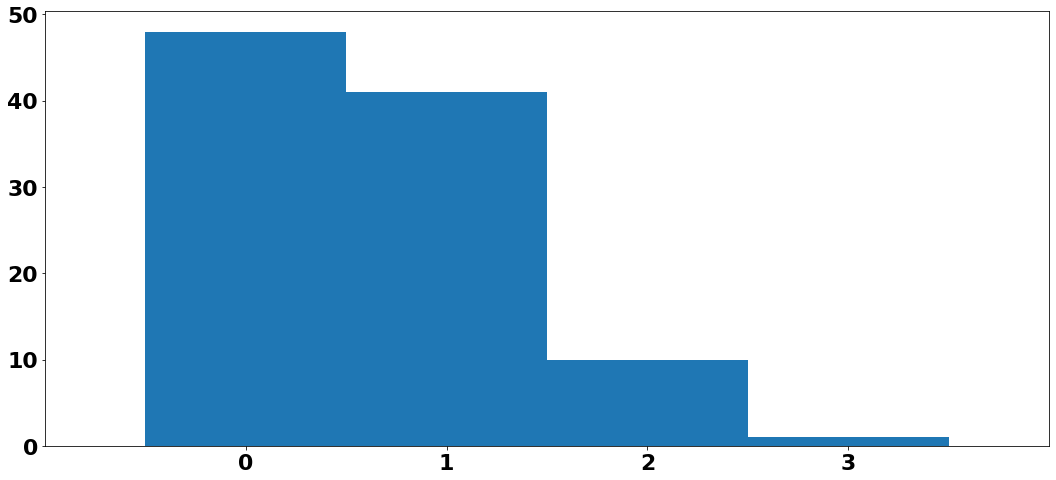

In [ ]:
hcs(3,100)

Após 100 tentativas, ou seja, 100 sequências de 3 HCs decididos em sequência, podemos plotar a distribuição de frequência do que observamos. Em cerca de 40 tentativas todos os 3 HCs foram improcedentes. Em cerca de 50 tentativas, 1 de 3 foi procedente. Em cerca de 10 tentativas, 2 de 3 foram procedentes. Em nenhuma das 100 tentativas todos os 3 foram procedentes.

O mundo observado não reflete exatamente a teoria da probabilidade. A discrepância entre o esperado e o observado, no entanto, diminui quando aumentamos o número de observações.

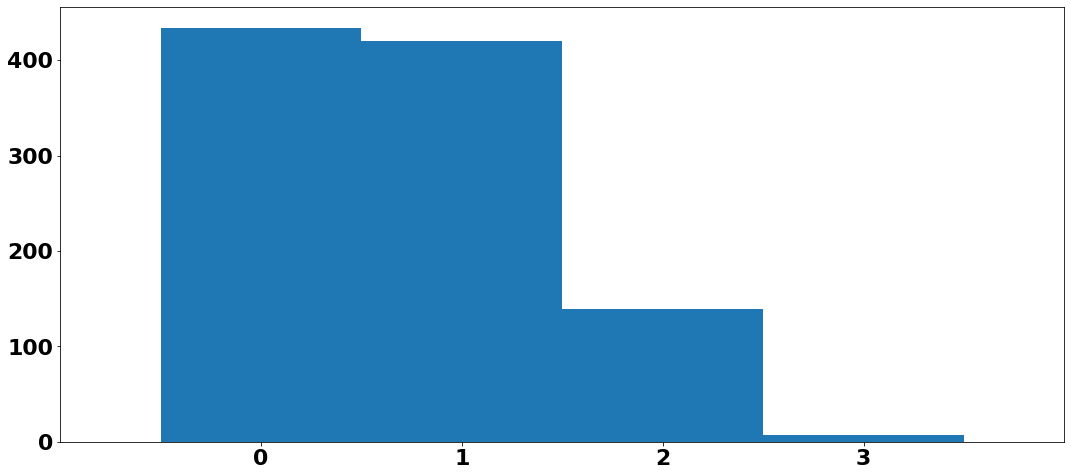

In [ ]:
hcs(3,1000)

Note que quando geramos aleatoriamente 1000 conjuntos de 3 decisões em HC no STF o resultado que esperamos em 1% dos conjuntos efetivamente aparece: 3 HCs decididos de forma favorável ao paciente em sequência.

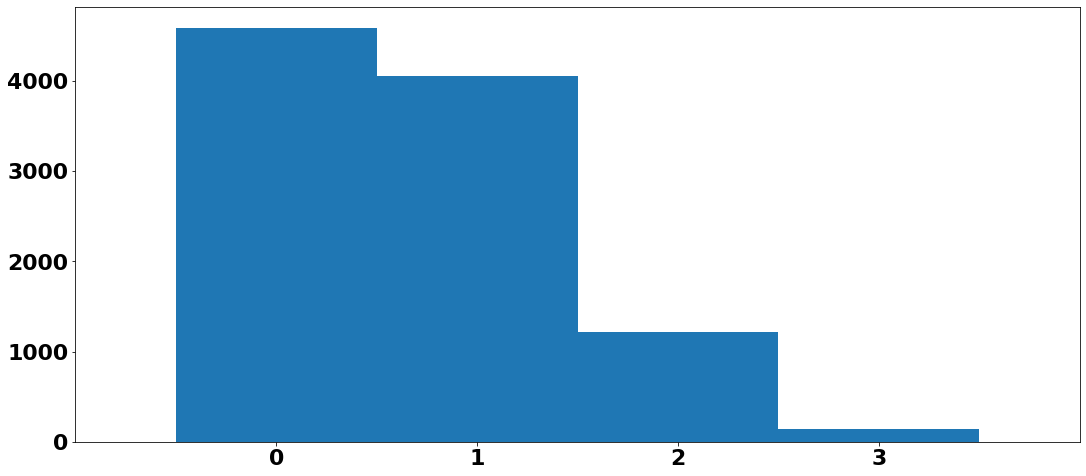

In [ ]:
hcs(3,10000)

Esse fenômeno normalmente é demonstrado com moedas e as chances de um resultado de cara ou coroa, como vimos acima. Mas qualquer evento no mundo do direito pode ser medido, tendo sua frequência testada e sua probabilidade teórica descrita: a chance de determinado tipo de emenda constitucional ser aprovada; a chance de determinado caso resultar em condenação superior a R$ 100.000; a chance de determinada conduta penalmente típica resultar em absolvição; a chance de determinada cláusula contratual ser judicialmente revista e revogada...

Observe o que acontece com a média de ocorrências do resultado 'procedencia' quando o total de observações de conjuntos de decisões de HC é muito grande - aproximando-se do infinito. 

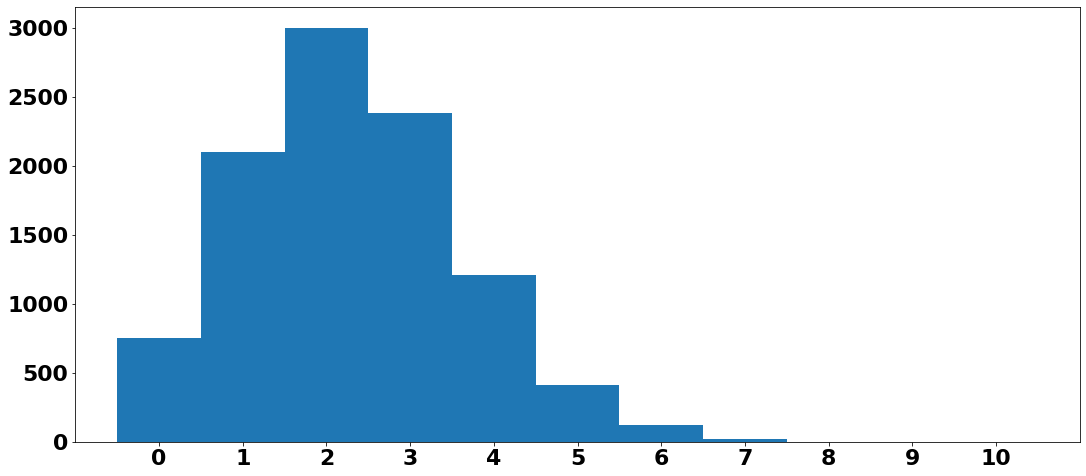

0.23041

In [ ]:
hcs(10,10000)

Quando o número de sorteios é grande o suficiente, a média da proporção de HCs procedentes em cada conjunto (seja ele de 3, 7, 10, 20 decisões, não importa) tende a ser igual à probabilidade de procedência de HCs na teoria.

A teoria sobre como se comportam distribuições de probabilidade permite produzir estimativas sobre a frequência de determinados resultados. 

Vamos comparar a teoria com o que é efetivamente observado nas simulações. Primeiro, alteramos a função que produz a simulação para que informe a média e desvio padrão da distribuição gerada. 

In [ ]:
def hcs(total_decisoes,total_observacoes,prob_procedencia=0.23):
  observacoes = []
  for decisoes in range(total_observacoes):
    teste = list(np.random.choice(['procedencia','nao procedencia'],size=total_decisoes,p=[prob_procedencia,1-prob_procedencia]))
    procedencias = teste.count('procedencia')
    observacoes.append(procedencias)
  plt.hist(observacoes,bins=np.arange(total_decisoes+2)-0.5)
  plt.xticks(range(total_decisoes+1))
  plt.xlim([-1,total_decisoes+1])
  plt.show()
  print('A média da proporção de HCs procedentes na distribuição é',round(np.mean(observacoes)/total_decisoes,2))
  print('O desvio padrão da distribuição é',round(np.std(observacoes),2))
 

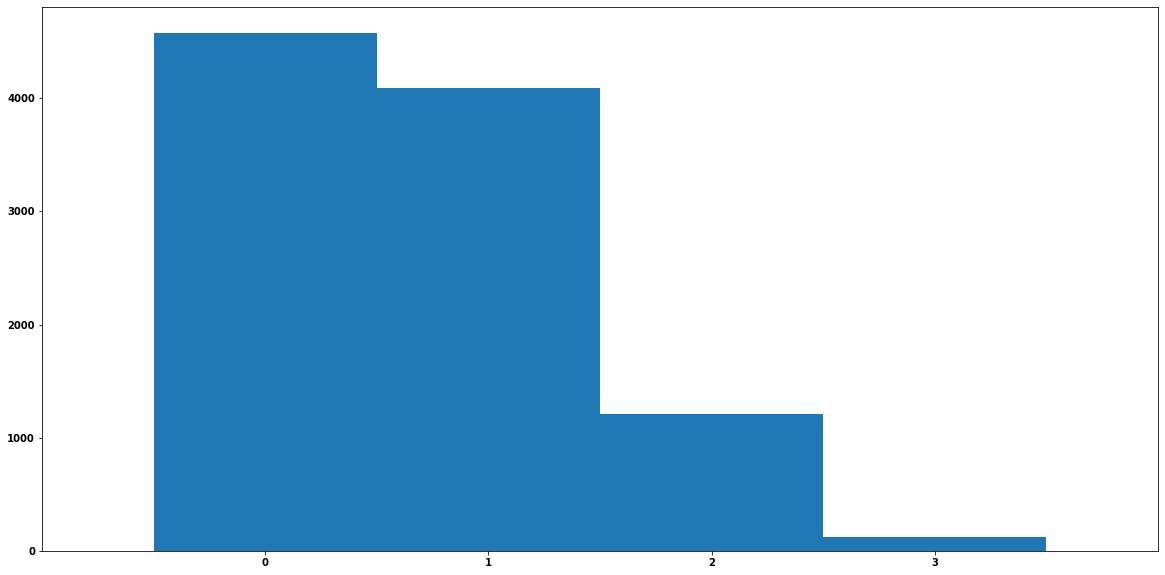

A média da proporção de HCs procedentes na distribuição é 0.23
O desvio padrão da distribuição é 0.73


In [ ]:
hcs(3,10000)

De posse apenas da informação sobre a probabilidade, podemos calcular a média e desvio padrão teóricos da distribuição de probabilidade:

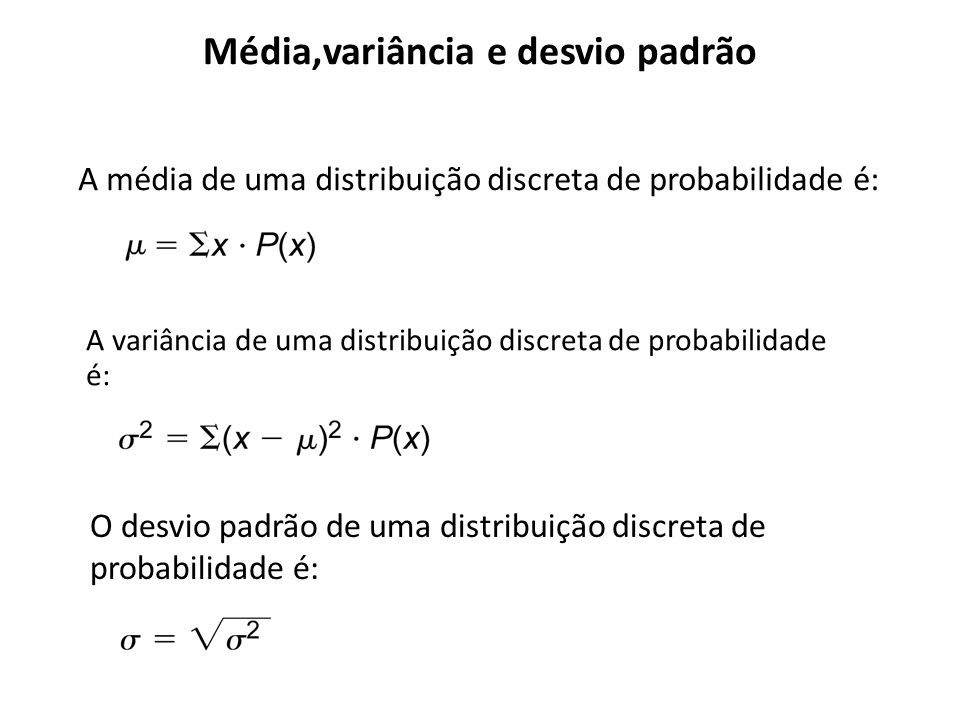

Utilize essas duas fórmulas para calcular a média e desvio padrão da distribuição de probabilidade da ocorrência de HCs procedentes a cada 3 HCs decididos pelo STF. Use como base o cálculo demonstrado no livro para homicídios resolvidos a cada 3 homicídios.

Podemos aprimorar nosso gráfico que plota a distribuição de observações para mostrar a demarcação do desvio padrão e expressar a proporção do total de observações que cada barra representa.

In [ ]:
def hcs(total_decisoes,total_observacoes,prob_procedencia=0.23):
  plt.rcParams["figure.figsize"] = (22, 11)
  font = {'weight':'bold','size': 18}
  matplotlib.rc('font', **font)
  observacoes = []
  for decisoes in range(total_observacoes):
    teste = list(np.random.choice(['procedencia','nao procedencia'],size=total_decisoes,p=[prob_procedencia,1-prob_procedencia]))
    procedencias = teste.count('procedencia')
    observacoes.append(procedencias)
    media = np.mean(observacoes)
    desvio = np.std(observacoes)
  a,b, barras = plt.hist(observacoes,bins=np.arange(total_decisoes+2)-0.5,color='blue',density=True)
  plt.axvspan(media-desvio,media+desvio,alpha=0.6,color='blue',label='1 desvio padrão = 68%')
  plt.axvspan(media-2*desvio,media+2*desvio,alpha=0.4,color='blue',label='2 desvios padrão = 95%')
  plt.axvspan(media-3*desvio,media+3*desvio,alpha=0.2,color='blue',label='3 desvios padrão = 99%')
  plt.xticks(range(total_decisoes+1))
  plt.xlim([-1,total_decisoes+1])
  for barra in barras:
    x = barra._x0 + 0.01
    y = barra._y1 + 0.003
    plt.text(x, y, round(barra._y1,3))
  plt.legend()
  plt.show()
  print('A média da proporção de HCs procedentes na distribuição é',round(media/total_decisoes,2))
  print('O desvio padrão da distribuição é',round(desvio,2))
 

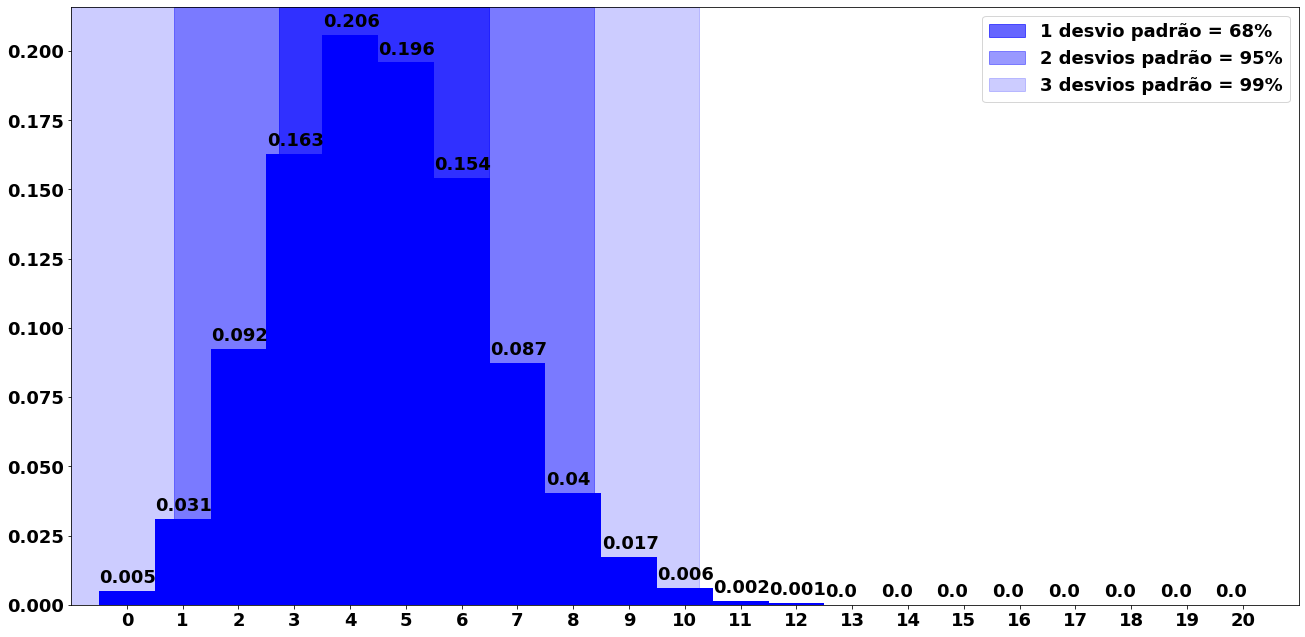

A média da proporção de HCs procedentes na distribuição é 0.23
O desvio padrão da distribuição é 1.88


In [ ]:
hcs(20,20000)

Some as proporções das barras que ficam dentro do espaço de cada faixa - 1 desvio padrão abaixo e acima da média; 2 desvios e 3 desvios. O valor é próximo do esperado? 

Usando única exclusivamente a probabilidade de 0.23 de uma HC favorável ao paciente é possível calcular a probabilidade teórica da ocorrência de cada número de HCs favoráveis na distribuição. O gráfico mostra que em 20 HCs a probabilidade de 8 serem favoráveis é de 0.045. 

Ou seja, sabendo apenas que a probabilidade de um HC favorável ao paciente no STF é 0.23, podemos determinar a probabilidade de que 8 em 20 HCs sejam favoráveis ao paciente usando o módulo 'stats' da biblioteca scipy. Cheque o segundo bloco de código para encontrar esse módulo sendo importado.

A função binom.pmf recebe como argumentos o total de decisões favoráveis, o total de decisões amostradas e a probabilidade teórica de que uma decisão seja favorável. Ela devolve um float com a probabilidade do evento descrito.


In [ ]:
stats.binom.pmf(8,20,0.23)

0.042852732468800336

A chamada de 'binom.pmf()' chegou à uma probabilidade muito similar à proporção encontrada na simulação. Enquanto na simulação a proporção de sorteios que resultaram em 8 de 20 HCs favoráveis foi de 0.045, o cálculo da probabilidade teórica resultou em 0.043.

A função que simula os sorteios segue o elemento de imprevisibilidade da vida real com sua aleatoriedade. A cada vez que nova série de sorteios forem realizados, a proporção de 8 de 20 HCs favoráveis pode variar e não ser exatamente 0.045. 

Já a função 'binom.pmf()' calcula a probabilidade teórica e, portanto, sempre retornará a mesma probabilidade a partir dos mesmos inputs.

Podemos somar os resultados de diferentes chamadas da função 'binom.pmf()' para identificar a probabilidade de números de ocorrências diferentes. Por exemplo, para obter a probabilidade teórica de 8, 9 ou 10 HCs favoráveis em 20 seguidos:

In [ ]:
stats.binom.pmf(8,20,0.23) + stats.binom.pmf(9,20,0.23) + stats.binom.pmf(10,20,0.23)

0.06552731373058485

EOF